In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)

from randomness import *
from df_metrics import *
from simulation_exact import *
from utils import *
from data_analysis import *
from main import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from joblib import Parallel, delayed
from itertools import product
import seaborn as sns

#seed = 42
#np.random.seed(seed)
#rng = np.random.default_rng(seed)

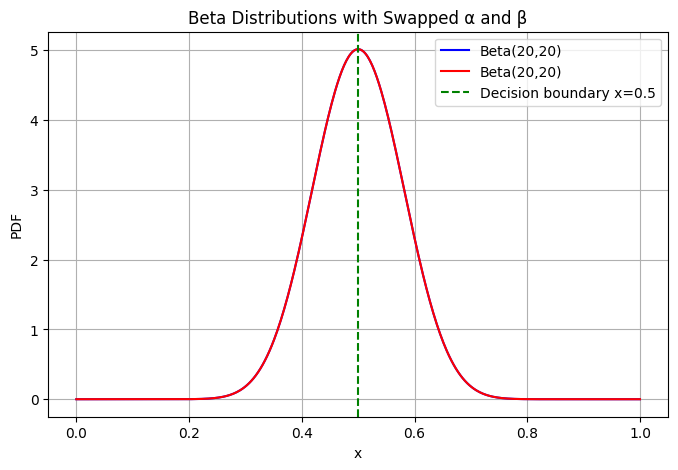

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Parameters
alpha = 20
beta_param = 20

# x values
x = np.linspace(0, 1, 500)

# Beta distributions
f1 = beta.pdf(x, alpha, beta_param)   # Beta(2,5)
f2 = beta.pdf(x, beta_param, alpha)   # Beta(5,2)

# Plot
plt.figure(figsize=(8,5))
plt.plot(x, f1, label=f'Beta({alpha},{beta_param})', color='blue')
plt.plot(x, f2, label=f'Beta({beta_param},{alpha})', color='red')
plt.axvline(0.5, color='green', linestyle='--', label='Decision boundary x=0.5')
plt.title('Beta Distributions with Swapped α and β')
plt.xlabel('x')
plt.ylabel('PDF')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
use_loss = 'hinge' #'log' or 'hinge' or 'squared_hinge' 
sigma_loss = 1.0 
c = 1.0 # choose c without scaling 
show_plots = False # set to True to see plots of the binary search
is_throw = True # set to True to throw out points outside margin --> only when loss is lipschitz. 
k = None # if none will be set based on data max norm
k_coef = 1.0 # coefficient to multiply k with
fit_intercept = True # whether to fit intercept in SVM model
ds = [2, 4, 8, 16, 32, 64] # dimensions to run experiments on
T = 200  # number of trials
w = 0.5

In [6]:
def generate_beta_data(n_neg, n_pos, alpha_neg, beta_neg, 
                       alpha_pos, beta_pos, rng, d=1):
    # Sample negative points
    neg_samples = rng.beta(alpha_neg, beta_neg, size=(n_neg, d))
    
    # Sample positive points
    pos_samples = rng.beta(alpha_pos, beta_pos, size=(n_pos, d))
    
    # Combine and return
    X = np.vstack([neg_samples, pos_samples])

    y = np.concatenate([-1 * np.ones(n_neg), np.ones(n_pos)])

    v = np.concatenate([np.ones(n_neg), np.ones(n_pos)])

    return X, y, v

In [7]:
# choose parameters 
n_pos = 50 # number of data points in a sample with label 1
n_neg = 50 # number of data points in a sample with label -1
n_val_pos = 200
n_val_neg = 200

alphas = [0.5,1,4,10]
betas = [0.5,1,4,10]
alphas_betas = [[i,j] for i in alphas for j in betas]
ms = range(100,1001,100)
ms = [30, 50] + list(ms)

In [ ]:
# 3. run exact sisigmalation
# returns df with cols "agent" | "true_v" | "critical_v" | "allocation" | "welfare" | "utility"
# utility = welfare - payment
# welfare = allocation * true_v
# critical_v = payment 

def compute_metrics_beta(t):
    dfs = []
    for m in ms:
        for tup in alphas_betas:
            alpha = tup[0]
            beta = tup[1]
            seed = hash((t, alpha, beta)) % (2**32)
            rng = np.random.default_rng(seed)
            #beta_neg = alpha_pos = beta 
            x, y, v =  generate_beta_data(m, m, alpha, beta, beta, alpha, rng, d = 1)
  
            #x_val, y_val, _ = generate_beta_data(n_val_neg, n_val_pos, alpha, beta, beta, alpha, beta_pos, rng, d)
            
            df_exact, svm_model = run_exact(x, y, v, c, use_loss, sigma_loss=sigma_loss, plot=show_plots, 
                                    is_throw=is_throw, k=k, k_coef=k_coef, fit_intercept=fit_intercept)
            df_exact['t'] = t
            #df_exact['d'] = d
            df_exact['beta_neg'] = beta
            df_exact['alpha_neg'] = alpha
            #df_exact['valid_acc'] = svm_model.score(x_val,y_val)
            df_exact['label'] = y[df_exact['agent'].astype(int)]
            dfs.append(df_exact)

    return pd.concat(dfs, ignore_index=True)

In [ ]:
chnage suppor for absolute !

In [16]:
T = 50
mega_df_beta_3 = pd.concat(  
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_metrics_beta)(t) for t in range(T)
        ), 
        ignore_index=True
)

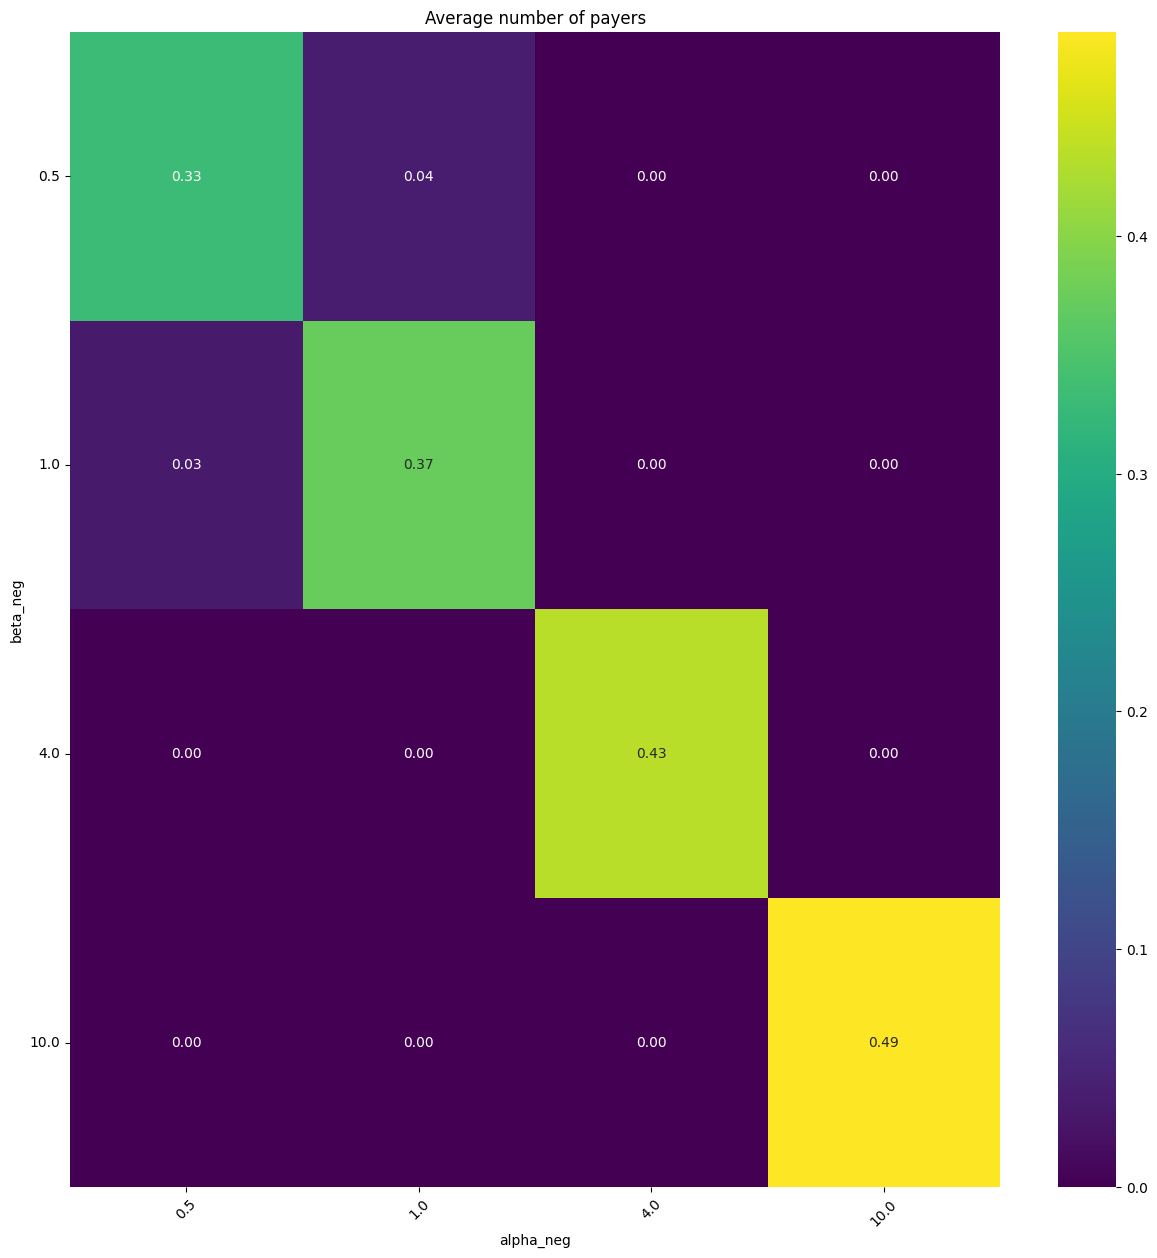

In [17]:

# df: your dataframe
# create a column for "paid" (1 if critical_v > 0, else 0)
mega_df_beta_3['paid'] = (mega_df_beta_3['critical_v'] > 0).astype(int)

# group by t, alpha_neg, beta_neg
grouped = mega_df_beta_3.groupby(['t', 'alpha_neg', 'beta_neg'])['paid'].mean().reset_index()

# now 'paid' is the **average number of payers** per group
grouped.rename(columns={'paid': 'avg_payers'}, inplace=True)

# pivot for heatmap
heatmap_data = grouped.pivot_table(index='beta_neg',
                              columns='alpha_neg',
                                values='avg_payers',
                                aggfunc='mean')

plt.figure(figsize=(15,15))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap='viridis')

# Set ticks at the center of each cell
plt.xticks(
    ticks=[i + 0.5 for i in range(len(heatmap_data.columns))],
    labels=[f"{v:.1f}" for v in heatmap_data.columns],
    rotation=45
)

plt.yticks(
    ticks=[i + 0.5 for i in range(len(heatmap_data.index))],
    labels=[f"{v:.1f}" for v in heatmap_data.index],
    rotation=0
)

plt.xlabel('alpha_neg')
plt.ylabel('beta_neg')
plt.title('Average number of payers')
plt.show()


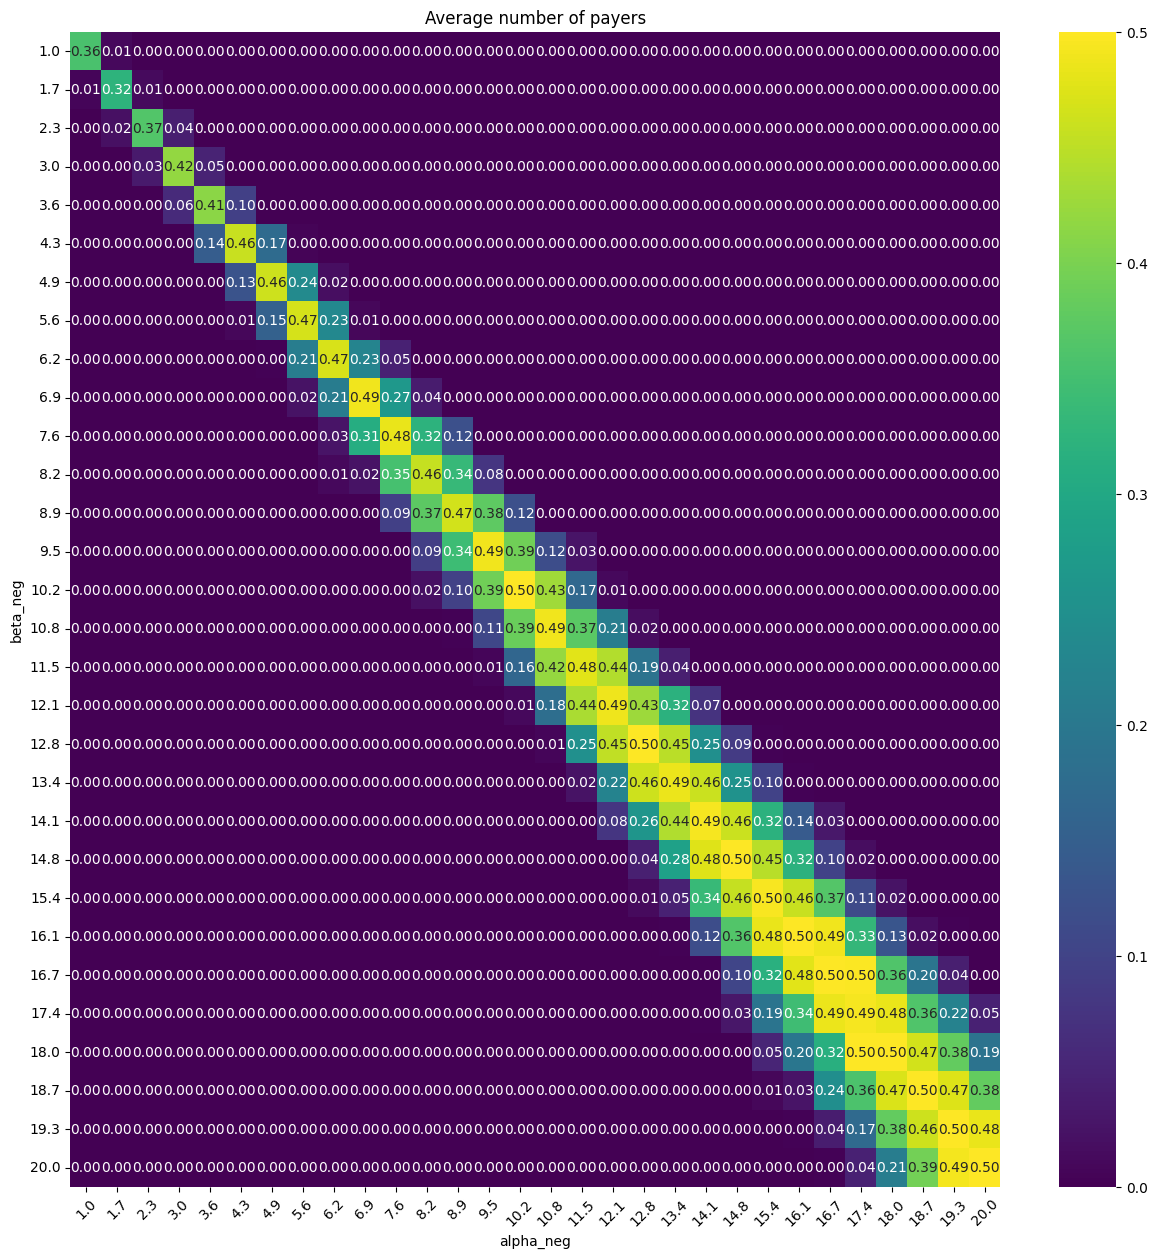

In [81]:

# df: your dataframe
# create a column for "paid" (1 if critical_v > 0, else 0)
mega_df_beta['paid'] = (mega_df_beta['critical_v'] > 0).astype(int)

# group by t, alpha_neg, beta_neg
grouped = mega_df_beta.groupby(['t', 'alpha_neg', 'beta_neg'])['paid'].mean().reset_index()

# now 'paid' is the **average number of payers** per group
grouped.rename(columns={'paid': 'avg_payers'}, inplace=True)

# pivot for heatmap
heatmap_data = grouped.pivot_table(index='beta_neg',
                              columns='alpha_neg',
                                values='avg_payers',
                                aggfunc='mean')

plt.figure(figsize=(15,15))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap='viridis')

# Set ticks at the center of each cell
plt.xticks(
    ticks=[i + 0.5 for i in range(len(heatmap_data.columns))],
    labels=[f"{v:.1f}" for v in heatmap_data.columns],
    rotation=45
)

plt.yticks(
    ticks=[i + 0.5 for i in range(len(heatmap_data.index))],
    labels=[f"{v:.1f}" for v in heatmap_data.index],
    rotation=0
)

plt.xlabel('alpha_neg')
plt.ylabel('beta_neg')
plt.title('Average number of payers')
plt.show()


In [49]:
mega_df_beta[(mega_df_beta['alpha_neg'] == 6)
             &(mega_df_beta['beta_neg'] == 4)]['critical_v'].unique()

array([0.])

In [ ]:
t = 1
d = 2
beta_neg = 10
alpha_neg = 2
beta_pos =  2
alpha_pos = 10
n_pos = 1000 # number of data points in a sample with label 1
n_neg = 1000 
seed = hash((t, d, beta)) % (2**32)
rng = np.random.default_rng(seed)
x, y, v =  generate_beta_data(n_neg, n_pos, alpha_neg, beta_neg, alpha_pos, beta_pos,rng, d = d)
plt.scatter(x[y==-1,0], x[y==-1,1], color='blue', label='Class 0', alpha=0.6)
plt.scatter(x[y==1,0], x[y==1,1], color='red', label='Class 1', alpha=0.6)


In [ ]:
def run_exact_w(x, y, v, c, w, use_loss, sigma_loss=sigma_loss, plot=show_plots, 
                                    is_throw=is_throw, k=k, k_coef=k_coef, fit_intercept=fit_intercept):
    M = np.sum(v)
    # svm_model = train_soft_svm(x, y, v, c = (c/M), loss = use_loss, fit_intercept=fit_intercept)
    relevant_indices, support_idx = relevant_func(x, y, v, w, (c/M), sigma_loss =  sigma_loss, k=None, k_coef=k_coef)

    if is_throw:
        throw = throw_func(x, y, v, w, (c/M), sigma_loss =  sigma_loss, k=None, k_coef=k_coef)
    else:
        throw = []

    records = []
    n = len(v)
    throw_set = set(throw)
    relevant_set = set(relevant_indices)
    support_set = set(support_idx)

    mask = np.ones(n, dtype=bool)
    mask[throw] = False

    new_x, new_y, new_v = x[mask], y[mask], v[mask]

    updated_relevant_indices = update_indices(relevant_indices, throw)
    real_to_updated = dict(zip(relevant_indices, updated_relevant_indices))

    # updated_relevant_indices = update_indices(support_idx, throw)
    # real_to_updated = dict(zip(support_idx, updated_relevant_indices))

    for target_idx in range(n):
        is_relevant = target_idx in relevant_set
        is_support = target_idx in support_set
        is_thrown = target_idx in throw_set

        if is_relevant: # or is_support
            updated_idx = real_to_updated[target_idx]
            critical_v, alloc, _ = compute_critical_bid(
                new_x, new_y, new_v, updated_idx,
                train_soft_svm,
                loss=use_loss,
                plot=plot,
                c=(c / M),
                fit_intercept=fit_intercept
            )
        else:
            alloc = int(svm_model.predict(x[target_idx].reshape(1, -1)) == y[target_idx])
            critical_v = 0

        records.append({
            "agent": target_idx,
            "allocation": alloc,
            "true_v": v[target_idx],
            "critical_v": critical_v,
            "welfare": v[target_idx] * alloc,
            "utility": v[target_idx] * alloc - critical_v,
            "is_relevant": int(is_relevant),
            "support": int(is_support),
            "is_throw": int(is_thrown),
        })

    df_exact = pd.DataFrame(records)
    return df_exact, svm_model

def relevant_func(x,y,v, w = 0.5, c = 1, sigma_loss =  sigma_loss, k=None, k_coef=k_coef, tol = 0):
    decision_values = x @ w 
    margin = y * decision_values

    # correctly classified *on-margin* support vectors: 0 < y*f(x) <= 1
    support_vector_mask = (margin > 0) & (margin <= 1)
    support_vector_indices = np.where(support_vector_mask)[0]

    # extract V for those points
    V_critical = v[support_vector_indices]

    # lambda = 1/C
    lam = 1.0 / c

    # compute k if not provided: max L2 norm of x
    if k is None:
        # print(f'k is none, computing from data')
        k = np.linalg.norm(x, axis=1).max()


    # compute beta values (vectorized)
    beta_values = ((k*k_coef)**2 * V_critical * sigma_loss) / (2 * lam)


    # select: margin < beta   (vectorized)
    selected_mask = margin[support_vector_indices] <  beta_values + tol
    relevant_indices = support_vector_indices[selected_mask]
    
    #print("margin, beta", support_vector_indices , margin[support_vector_indices] ,  beta_values[0])
    return relevant_indices, support_vector_indices

def throw_func(x,y,v, w = 0.5, c = 1, sigma_loss =  sigma_loss, k=None, k_coef=k_coef, tol = 0):
    decision_values = x @ w 
    margin = y * decision_values

    # points outside the margin: y*f(x) > 1
    outside_margin_mask = margin > 1 
    outside_margin_indices = np.where(outside_margin_mask)[0]
   
    # extract V for those points
    V_critical_outside = v[outside_margin_indices]
    
    # lambda = 1/C
    lam = 1.0 / c

    # compute k if not provided: max L2 norm of x
    if k is None:
        k = np.linalg.norm(x, axis=1).max()

    # compute beta values (vectorized)
    beta_values_outside = ((k*k_coef)**2 * (V_critical_outside) * sigma_loss) / (2 * lam)

    # final outside selection: margin > 1 + beta
    selected_mask = margin[outside_margin_indices] > (1 + beta_values_outside) + tol
    throw = outside_margin_indices[selected_mask]
    #print("margin, beta", outside_margin_indices , margin[outside_margin_indices] ,  beta_values_outside[0])

    return throw


def compute_critical_bid(x, y, v, target_idx, allocation_rule, loss = 'hinge', tol=1e-10, max_iter=10000, c=1,
                          plot = True, fit_intercept=True):
    v_mod = v.copy()
    min_v, max_v = 0.0, v[target_idx] 
    
    # Early check at v = 0
    v_mod[target_idx] = min_v
    alloc_0, model_0 = check_and_plot(x, y, v_mod, target_idx, allocation_rule, loss = 'hinge', c=c, 
                                      plot = plot, fit_intercept=fit_intercept)
    if alloc_0 == 1:
        return min_v, alloc_0 , model_0
    
    #no need for early check at v_max, all points entering here have alloc = 1

    # Binary search
    low, high = min_v, max_v
    alloc_mid = 0  # Initialize in case loop does not run
    model_mid = None
    critical_v = None
    for i in range(max_iter):
        mid = (low + high) / 2.0
        v_mod[target_idx] = mid
        alloc_mid, model_mid = check_and_plot(x, y, v_mod, target_idx, allocation_rule, c=c,
                                              loss = 'hinge', plot = plot, fit_intercept=fit_intercept)

        if alloc_mid == 1:
            high = mid
        else:
            low = mid

        if high - low < tol and alloc_mid == 1:
            critical_v = (low + high) / 2.0
            break

    
    if i == max_iter - 1:
        print("Warning: reached max iterations")
    if alloc_mid == 0 or critical_v is None:
        print("Warning: alloc_mid is still 0 or critical_v is none")
        print(f"alloc mid =", alloc_mid)
        print(f"high, low", high, low)
        print(f"critical_v =", critical_v)
        print(f"iter =", i)
        alloc_mid = 1
        critical_v = v[target_idx]
    return critical_v, alloc_mid, model_mid 

